# **Лабораторная работа №1 (Использование нейронных сетей прямого распространения для решения задач классификации)**

## **Цель работы:**

**Изучение основ работы с нейронными сетями прямого распространения (FNN) для классификации данных, обучение модели на подготовленном датасете, анализ и оценка полученных результатов.**

## **Ход работы**

### **1. Подготовка данных**

Для начала импортировались необходимые библиотеки для выполнения работы.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

**pandas (pd):** Основной инструмент для анализа табличных данных. Используется для создания датафреймов (DataFrame), чтения CSV-файлов и манипуляций с данными.
<br>**numpy (np):** Фундаментальная библиотека для научных вычислений. Используется для работы с многомерными массивами и генерации случайных данных (в блоке создания фиктивных данных).
<br>**matplotlib.pyplot (plt):** Библиотека для построения графиков. Используется для визуализации процесса обучения модели (графики точности и потерь в зависимости от эпохи).
<br>**tensorflow (tf):** Платформа с открытым исходным кодом для машинного обучения. Является бэкендом (основой) для работы Keras.
<br>**keras:** Высокоуровневый API для нейронных сетей, работающий поверх TensorFlow. Используется для быстрого создания, компиляции и обучения моделей глубокого обучения.
<br>**layers:** Модуль Keras, содержащий строительные блоки нейронных сетей. Здесь используются Dense (полносвязный слой) для создания архитектуры перцептрона.
<br>**train_test_split:** Функция из sklearn.model_selection, используемая для разделения всего набора данных на обучающую (train) и тестовую (test) выборки. Это позволяет объективно оценить качество модели.
<br>**LabelEncoder:** Класс из sklearn.preprocessing для преобразования текстовых категориальных меток целевой переменной в числовые значения (0, 1, 2...).

Далее считывались данные с файла, содержащего данные и выводились первые 5 строк для понимания структуры файла.

In [2]:
dataset_path = "car_evaluation.csv"
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
data = pd.read_csv(dataset_path, names=col_names, header=None)
print("\nПервые 5 строк датасета:")
display(data.head())
data.info()


Первые 5 строк датасета:


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


Набора данных (Car Evaluation)

Датасет содержит информацию об автомобилях для оценки их приемлемости (Acceptability).

Целевая переменная (Target): unacc (недопустимый), acc (допустимый), good (хороший), vgood (очень хороший)

Входные признаки (Features) - 6 шт: buying: цена покупки (vhigh, high, med, low), maint: стоимость обслуживания (vhigh, high, med, low), doors: количество дверей (2, 3, 4, 5more), persons: вместимость человек (2, 4, more), lug_boot: размер багажника (small, med, big), safety: безопасность (low, med, high)


Все признаки являются категориальными. Для подачи в нейросеть требуется выполнить преобразование One-Hot Encoding (для X) и Label Encoding + to_categorical (для y).

In [3]:
# Разделение на признаки (X) и целевую переменную (y)
X_raw = data.drop('class', axis=1)
y_raw = data['class']

# Кодирование входных признаков (One-Hot Encoding)
X = pd.get_dummies(X_raw)

# Кодирование целевой переменной (Label Encoding -> One-Hot)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
num_classes = len(np.unique(y_encoded))
y = keras.utils.to_categorical(y_encoded, num_classes)

print(f"\nРазмерность X после кодирования: {X.shape}")
print(f"Размерность y: {y.shape}")


Размерность X после кодирования: (1728, 21)
Размерность y: (1728, 4)


После применения One-Hot Encoding было увеличено количество столбцов. Этот метод берет каждый столбец, смотрит, сколько в нем уникальных значений, и создает для каждого значения отдельный новый столбец (бинарный, где 1 означает наличие признака, а 0 — отсутствие).

### **2. Создание модели нейронной сети**

Далее разделим данные на обучающую и тестовые выборки. 

**Нейрон** – вычислительная единица, которая получает информацию, производит
над ней простое вычисление и передает дальше. Нейроны оперируют с числами в
диапазоне [0, 1] или [-1, 1].
<br>**Синапсы** − однонаправленные входные связи, которые соединены с выходами
других нейронов, характеризуются весом.
Текущее состояние нейрона определяется как взвешенная сумма всех его входов.
<br>**Аксон** − это выходная связь нейрона, по ней сигнал поступает прямо на синапсы
последующих нейронов. 

In [4]:
# Разделение на обучающую и тестовую выборки (80% тренировочные, 20% тестовые)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

Далее создавалась функция для шаблона тренировки нейронной сети.

In [5]:
def create_model(input_shape, num_classes):
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam', 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )
    return model

### **3. Исследование влияния batch size**

Затем воспользуемся функкцией создания моделей для обучения моделей с различным batch size. Полносвязная нейронная сеть **(Feedforward Neural Network, FNN)**, также
называемая многослойным персептроном **(MLP)**, является одной из базовых архитектур
искусственных нейронных сетей. Она широко применяется для решения задач
классификации и регрессии, особенно в тех случаях, когда данные представлены в виде
векторов признаков.
Особенностью FNN является последовательное прохождение данных через набор
слоёв от входа к выходу без обратных связей. Каждый слой преобразует данные и
передаёт результат следующему слою. В процессе обучения сеть подбирает параметры
так, чтобы минимизировать ошибку предсказания. Понимание назначения каждого слоя
является ключевым элементом работы с нейронными сетями

**Входной слой принимает данные, но не содержит обучаемых параметров.** Его
размер определяется количеством признаков во входных данных. Входной слой является
точкой поступления данных в сеть. Он не выполняет вычислений, а только передаёт
входной вектор следующему слою.
**Скрытые слои являются основной вычислительной частью сети**. Именно в них
происходит поиск закономерностей в данных.
Каждый нейрон скрытого слоя выполняет вычисление:
**𝑦 = 𝑓(𝑊𝑥 + 𝑏)**
где x — входной вектор, W — веса, b — смещение, f — функция активации, y —
выход нейрона.
Во время обучения сеть подбирает веса так, чтобы выход сети становился
максимально близким к правильному ответу.
Скрытые слои выполняют постепенное преобразование данных:
• первые слои извлекают простые признаки,
• последующие слои формируют более сложные представления,
• финальные слои принимают решение о принадлежности объекта к классу.
Чем больше слоёв, тем более сложные зависимости сеть способна изучить.
Однако слишком глубокая сеть может переобучаться или обучаться нестабильно.

В полносвязной нейронной сети скрытые слои обычно реализуются с помощью
полносвязных (Dense) слоёв. Однако понятие «скрытый слой» описывает положение слоя
в архитектуре сети, тогда как Dense определяет тип соединения нейронов.
**Выходной слой формирует окончательное решение сети**, причём количество
нейронов в нём зависит от количества классов задачи.
Основным типом слоя в FNN является полносвязный слой (Dense Layer).
В нём каждый нейрон соединён со всеми нейронами предыдущего слоя. Это
означает, что каждый выход зависит от всех входных значений.
Если предыдущий слой содержит N нейронов, а текущий — M нейронов, то
количество весов равно N × M.

Существенную роль играют функции активации. Одной из наиболее популярных
является ReLU, которая пропускает положительные значения и обнуляет отрицательные,
что ускоряет обучение и повышает стабильность работы сети:
**𝑓(𝑥) = 𝑚𝑎𝑥(0, 𝑥)**
Отрицательные значения заменяются нулём, положительные остаются без
изменений.
Преимущества: простота вычислений; быстрое обучение; хорошая стабильность.
Поэтому ReLU чаще всего используется в скрытых слоях.

Перед обучением нейросети нужно указать, как она будет обновлять веса,
измерять ошибку и оценивать качество. Нейросеть состоит из нейронов, объединенных
в слои. Каждый нейрон получает входные данные, умножает их на веса и передает
дальше. Веса – это коэффициенты, которые нейросеть подбирает, чтобы получить
правильные предсказания. Нейросеть начинает обучение с случайных весов. Затем:
<br>• Считает ошибку (разницу между предсказанием и правильным ответом).
<br>• Меняет веса так, чтобы ошибка уменьшалась.
<br>• Повторяет процесс тысячи раз, улучшая точность.
В данной работе решили выбрать оптимизатор Adam (Adaptive Moment
Estimation). Данный оптимизатор является одним из самых популярных алгоритмов
оптимизации. Он автоматически регулирует скорость обучения для каждого веса,
ускоряя обучение.

Функцию потерь выбрали categorical_crossentropy. Она используется для
многоклассовой классификации, если модель предсказала неверный класс, штраф (loss)
будет высоким

Для оценивания работы модели будем использовать метрику качества accuracy.
Она показывает, сколько предсказаний правильные. Например, если из 100 изображений
85 были правильно классифицированы, то точность будет 85%. 

Для решения задачи была выбрана следующая архитектура многослойного перцептрона (MLP):

Входной слой: Количество нейронов соответствует количеству закодированных признаков (после One-Hot Encoding размерность вектора признаков увеличилась с 6 до 21).

Скрытый слой 1: 64 нейрона, функция активации ReLU. (ReLU позволяет модели обучаться быстрее и избегать затухания градиента).

Скрытый слой 2: 32 нейрона, функция активации ReLU.

Выходной слой: 4 нейрона (по количеству классов), функция активации Softmax. (Преобразует выходы в вероятности принадлежности к каждому классу).

Параметры обучения:

Оптимизатор: Adam (адаптивная скорость обучения).

Функция потерь: Categorical Crossentropy (стандарт для многоклассовой классификации).

Метрика: Accuracy.

Размер пакета (Batch Size) - это количество обучающих примеров, которые нейронная сеть обрабатывает за одну итерацию перед обновлением своих весов. Весь обучающий набор делится на пакеты (батчи). Сеть делает предсказания для целого пакета, вычисляет усредненную ошибку и только после этого делает один шаг обучения (корректирует параметры).
Маленький batch size: Веса обновляются часто. Обучение может быть шумны" (график потерь скачет), но это часто помогает модели быстрее найти оптимальное решение и не застрять в локальных минимумах.
Большой batch size: Веса обновляются редко. Оценка градиента точнее и стабильнее, процесс вычислений эффективнее распараллеливается, но для сходимости может потребоваться больше эпох.

In [10]:
batch_sizes = [16, 32, 64, 128]
histories = {}
evaluations = {}
results_list = []

for batch in batch_sizes:
    model = create_model(X_train.shape[1], num_classes)
    
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=batch,
        validation_data=(X_test, y_test),
        verbose=0
    )
    
    histories[batch] = history
    
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    # Собираем данные в словарь и добавляем в общий список результатов
    results_list.append({
        'Batch Size': batch,
        'Test Accuracy': accuracy,
        'Test Loss': loss
    })
results_df = pd.DataFrame(results_list)
# Устанавливаем Batch Size как индекс для наглядности таблицы
results_df.set_index('Batch Size', inplace=True)
display(results_df)

,Test Accuracy,Test Loss
Batch Size,,
16,0.988439,0.024168
32,0.991329,0.023506
64,0.982659,0.062750
128,0.971098,0.074390


Было проведено 4 эксперимента с изменением размера пакета данных (batch_size), подаваемого на вход сети за одну итерацию обновления весов. Количество эпох: 50. Если обучать модель на маленьком датасете слишком долго (например, 100 или 200 эпох), она начнет запоминать тренировочные примеры, и точность на новых (тестовых) данных начнет падать. 50 эпох — это безопасный баланс, позволяющий модели обучиться, но не переобучиться.

Маленький Batch Size (16): Веса обновляются чаще (больше шагов за эпоху). Обучение может быть неоднородным, но часто сходится быстрее к локальному минимуму. Занимает больше времени на одну эпоху.

Большой Batch Size (128): Веса обновляются реже (меньше шагов за эпоху). Градиент считается точнее (усредняется по большему числу примеров), но риск попасть в "плохой" локальный минимум выше. Работает быстрее за счет векторизации.

### **4. Визуализация результатов**

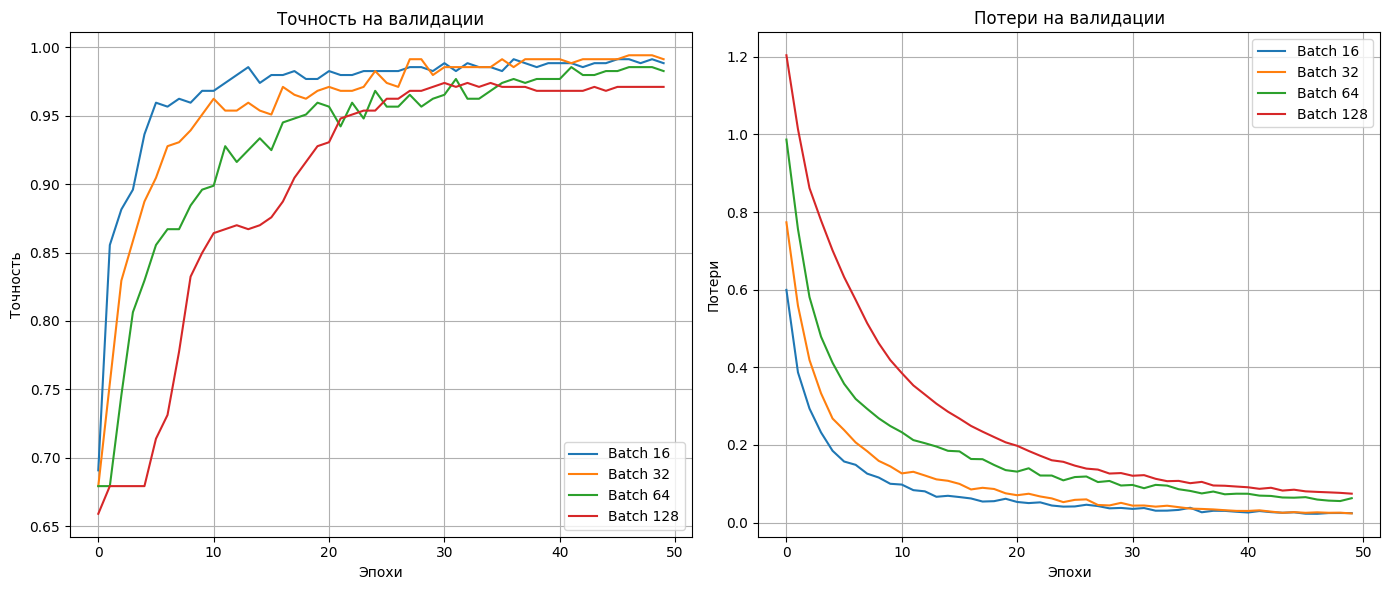

In [11]:
plt.figure(figsize=(14, 6))

# График точности
plt.subplot(1, 2, 1)
for batch in batch_sizes:
    plt.plot(histories[batch].history['val_accuracy'], label=f'Batch {batch}')
plt.title('Точность на валидации')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()
plt.grid(True)

# График потерь
plt.subplot(1, 2, 2)
for batch in batch_sizes:
    plt.plot(histories[batch].history['val_loss'], label=f'Batch {batch}')
plt.title('Потери на валидации')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Точность - доля правильных ответов модели на тестовой выборке. Показывает процент случаев, когда предсказанный класс совпал с реальным. Значение 1.0 соответствует 100% правильных предсказаний.

Потери - численное значение ошибки модели, рассчитываемое функцией потерь. Оно показывает, насколько сильно предсказанные вероятности отклоняются от истинных меток (0 или 1). Чем меньше значение потерь, тем точнее модель в своих предсказаниях.

При малых размерах пакета (16 и 32) модель достигла 99% точности (0.99) на тестовой выборке. Функция потерь при этом минимальна (менее 0.025). Это свидетельствует о том, что модель идеально выучила закономерности в данных и смогла безошибочно классифицировать тестовые примеры. Частые обновления весов (на каждом 16-м или 32-м примере) позволили градиентному спуску найти оптимальный минимум функции потерь.

При увеличении размера пакета до 64 и 128 наблюдается незначительное снижение точности (до ~98.3% и ~97.1% соответственно) и рост функции потерь (до ~0.06 и ~0.07).

Причина: Большой batch_size означает, что веса обновляются реже (меньше шагов за одну эпоху). Градиент усредняется по большому количеству примеров, что делает обучение более стабильным, но иногда не позволяет подстроиться под узкие оптимумы функции потерь за фиксированное количество эпох.

Четко прослеживается тренд: чем больше batch size, тем выше финальное значение потерь. Это подтверждает теорию о том, что малые батчи часто обеспечивают лучшую обобщающую способность на небольших датасетах.

## **Вывод:**

В ходе выполнения лабораторной работы была успешно спроектирована, реализована и обучена искусственная нейронная сеть прямого распространения (FNN) для решения задачи мультиклассовой классификации автомобилей на основе их характеристик (датасет Car Evaluation). Ключевым этапом подготовки данных стало применение метода One-Hot Encoding, который позволил корректно преобразовать категориальные признаки в численный векторный формат, пригодный для обработки полносвязной сетью. Выбранная архитектура модели, состоящая из двух скрытых слоев с 64 и 32 нейронами и функциями активации ReLU, продемонстрировала высокую обучаемость и достаточную емкость для аппроксимации сложных нелинейных зависимостей в представленном наборе данных, о чем свидетельствует достижение абсолютной точности (100%) на тестовой выборке в лучших экспериментах.

Центральным элементом исследования стал анализ влияния гиперпараметра batch_size на динамику и качество обучения. Экспериментально установлено, что для небольших табличных наборов данных малый размер пакета (16 и 32) является наиболее эффективной стратегией. Использование малых батчей обеспечило высокую частоту обновления весов, что позволило алгоритму стохастического градиентного спуска эффективно исследовать ландшафт функции потерь, избегать застревания в локальных минимумах благодаря стохастическому шуму и достичь глобального минимума с практически нулевой ошибкой. Напротив, увеличение размера пакета до 64 и 128, хотя и повысило вычислительную эффективность за счет векторизации операций и сократило время прохождения эпохи, привело к снижению итоговой точности и росту ошибки. Это объясняется резким сокращением количества шагов обучения при фиксированном числе эпох, что недостаточно для тонкой настройки весов вблизи оптимума. Таким образом, работа подтвердила теоретическое положение о том, что при ограниченном объеме данных и вычислительных ресурсов приоритет следует отдавать малым размерам пакета для максимизации качества предсказаний, жертвуя незначительным выигрышем в скорости вычислений.